# EDA: cleaned grammar-point appendix (`outcome/processed.md`)

`docs/process.md` fixed headings/boilerplate/bold; this notebook mines the
result for volume, distribution, and (more importantly) structural
anomalies that the 7-page benchmark (`docs/benchmark_result.md`) can't see,
since it only checked recall on 7 of 85 pages. If OCR silently dropped a
whole grammar point or heading somewhere in the other 78 pages, a numbering
gap or an orphan heading is the only way to catch it without ground truth.

In [1]:
import sys
from pathlib import Path

ROOT = Path("/home/nguyenlog205/projects/university/semester65/chinese-contents/chinese-grammar")
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams["font.sans-serif"] = ["Noto Sans CJK SC", "DejaVu Sans"]
mpl.rcParams["axes.unicode_minus"] = False

from src.common.eda import parse_document, numbering_gaps, heading_code_gaps, canonical_prefix, split_label_items, CROSSREF_RE

PROCESSED = ROOT / "outcome/processed.md"
text = PROCESSED.read_text(encoding="utf-8")
print(f"{PROCESSED}: {len(text.splitlines())} lines")

/home/nguyenlog205/projects/university/semester65/chinese-contents/chinese-grammar/outcome/processed.md: 6255 lines


## 1. Parse `processed.md` into structured data

`src/common/eda.py` walks the file once: `### 1.1` tracks the heading stack
(level → (code, title)) as it scans, `### 1.2` matches each `【prefix+num】`
bullet against the current stack to get its category path, `### 1.3` counts
the non-header, non-bullet lines that follow a bullet as its example lines
(and pulls out `见【...】` cross-refs from both the label and the examples),
`### 1.4` is the tidy DataFrame everything below reads from.

In [2]:
points, headings = parse_document(text)
print(f"{len(points)} grammar points, {len(headings)} headings")

df = pd.DataFrame([{
    "line_no": p.line_no,
    "page": p.page,
    "level_code": p.level_code,
    "level_title": p.level_title,
    "category_path": p.category_path,
    "prefix_raw": p.prefix_raw,
    "prefix": p.prefix,
    "number": p.number,
    "label": p.label,
    "n_example_lines": p.n_example_lines,
    "example_char_count": p.example_char_count,
    "n_cross_refs": len(p.cross_refs),
    "cross_refs": p.cross_refs,
} for p in points])

hdf = pd.DataFrame(headings)
df.head()

572 grammar points, 283 headings


,line_no,page,level_code,level_title,category_path,prefix_raw,prefix,number,label,n_example_lines,example_char_count,n_cross_refs,cross_refs
0,17,176,A.1,一级语法点,词类 > 名词,一,一,1,方位名词：上、下、里、外、前、后、左、右、东、南、西、北；上边、下边、里边、外边、前边、后边...,15,72,0,[]
1,53,176,A.1,一级语法点,词类 > 动词,一,一,2,能愿动词：会、能,2,14,0,[]
2,59,176,A.1,一级语法点,词类 > 动词,一,一,3,能愿动词：想、要,2,12,0,[]
3,67,176,A.1,一级语法点,词类 > 代词,一,一,4,疑问代词：多、多少、几、哪、哪儿、哪里、哪些、什么、谁、怎么,10,68,0,[]
4,93,177,A.1,一级语法点,词类 > 代词,一,一,5,人称代词：我、你、您、他、她、我们、你们、他们、她们,7,48,0,[]


## 2. Structural integrity checks

### 2.1 Heading code continuity
Sibling codes under the same parent (e.g. `A.1.1`, `A.1.2`, ... under
parent `A.1`) should increase by exactly 1. Any gap is either a missed
heading or a numbering skip in the source itself.

In [3]:
h_gaps = heading_code_gaps(headings)
print(f"heading numbering gaps: {len(h_gaps)}")
pd.DataFrame(h_gaps)

heading numbering gaps: 0


""


### 2.2 Bracket-label numbering continuity

Raw prefixes before canonicalization: this is where the OCR dash/punctuation
noise shows up (`七一九` / `七—九` for "七至九", trailing `.` on `五`).

In [4]:
print("raw prefix value counts:")
df["prefix_raw"].value_counts()

raw prefix value counts:


prefix_raw
七一九    146
三       81
二       81
四       76
五       68
六       67
一       48
五.       3
七—九      2
Name: count, dtype: int64

Same check after canonicalizing (`canonical_prefix`, `src/common/eda.py`): this is the real answer.

In [5]:
gaps = numbering_gaps(points)
gaps_df = pd.DataFrame(gaps).T
gaps_df

,count,min,max,duplicates,missing
一,48,1,48,[],[]
二,81,1,81,[],[]
三,81,1,81,[],[]
四,76,1,76,[],[]
五,71,1,71,[],[]
六,67,1,67,[],[]
七至九,148,1,148,[],[]


In [6]:
bad = {k: v for k, v in gaps.items() if v["missing"] or v["duplicates"]}
if bad:
    print("REAL gaps/duplicates after canonicalization:")
    for k, v in bad.items():
        print(k, v)
else:
    print("No real numbering gaps or duplicates once OCR dash/punctuation variants are canonicalized.")

No real numbering gaps or duplicates once OCR dash/punctuation variants are canonicalized.


### 2.3 Orphan / mismatch check

Every grammar point should resolve to a non-empty `level_code` (its `##`
grade heading) and a non-empty `category_path` (at least one `###`+ heading
above it). An empty value means a bullet appeared before any heading was
seen for that slot.

In [7]:
orphans = df[(df["level_code"] == "") | (df["category_path"] == "")]
print(f"orphan grammar points: {len(orphans)}")
orphans

orphan grammar points: 0


,line_no,page,level_code,level_title,category_path,prefix_raw,prefix,number,label,n_example_lines,example_char_count,n_cross_refs,cross_refs


## 3. Distribution / volume

### 3.1 Grammar points per grade level

findfont: Failed to find font weight normal, now using 100.


findfont: Failed to find font weight normal, now using 100.


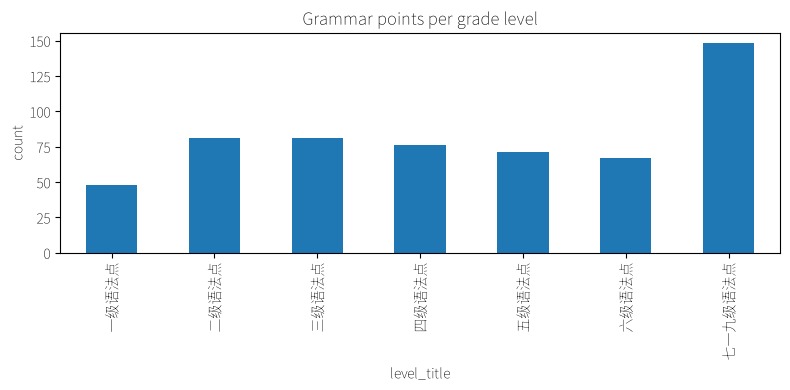

level_title
一级语法点       48
二级语法点       81
三级语法点       81
四级语法点       76
五级语法点       71
六级语法点       67
七一九级语法点    148
Name: count, dtype: int64

In [8]:
level_order = ["一级语法点", "二级语法点", "三级语法点", "四级语法点", "五级语法点", "六级语法点", "七一九级语法点"]
counts = df["level_title"].value_counts().reindex(level_order)
counts.plot(kind="bar", figsize=(8, 4), title="Grammar points per grade level")
plt.ylabel("count")
plt.tight_layout()
plt.show()
counts

### 3.2 Grammar points per category × grade level (heatmap)

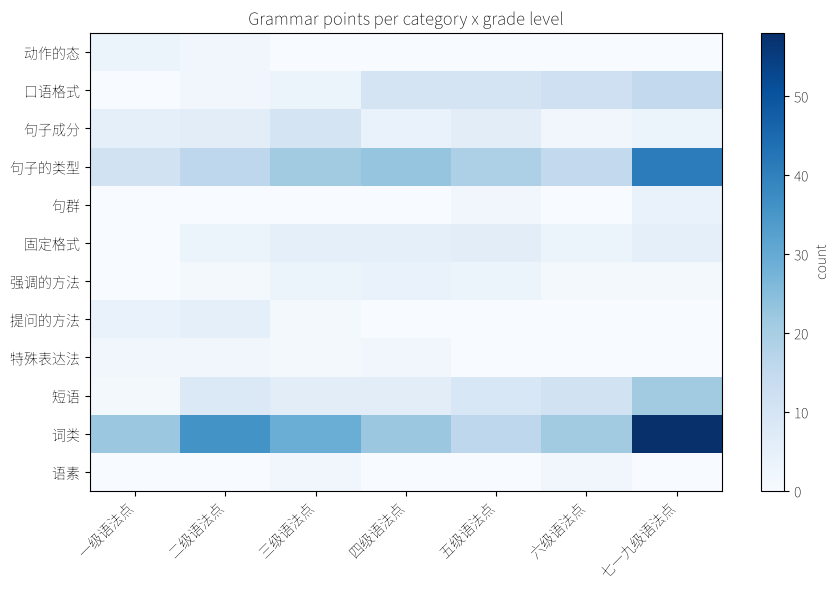

level_title,一级语法点,二级语法点,三级语法点,四级语法点,五级语法点,六级语法点,七一九级语法点
category_top,,,,,,,
动作的态,3,2,0,0,0,0,0
口语格式,0,2,3,10,10,12,15
句子成分,5,6,10,4,6,2,3
句子的类型,11,16,21,23,19,15,41
句群,0,0,0,0,2,0,4
固定格式,0,3,5,5,6,3,5
强调的方法,0,1,3,4,3,1,1
提问的方法,4,5,1,0,0,0,0
特殊表达法,2,2,1,2,0,0,0


In [9]:
df["category_top"] = df["category_path"].str.split(" > ").str[0]
pivot = df.pivot_table(index="category_top", columns="level_title", values="number", aggfunc="count", fill_value=0)
pivot = pivot.reindex(columns=[c for c in level_order if c in pivot.columns])

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(pivot.values, aspect="auto", cmap="Blues")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_title("Grammar points per category x grade level")
fig.colorbar(im, ax=ax, label="count")
plt.tight_layout()
plt.show()
pivot

### 3.3 Example-sentence coverage per grammar point

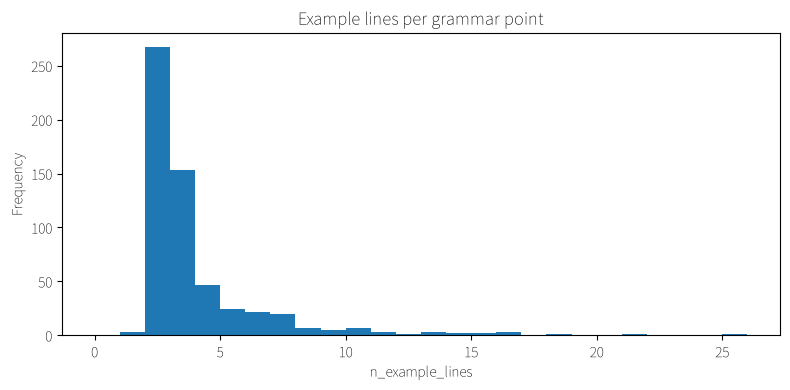

grammar points with zero example lines: 0


,line_no,page,level_title,category_path,prefix,number,label


In [10]:
df["n_example_lines"].plot(kind="hist", bins=range(0, df["n_example_lines"].max() + 2), figsize=(8, 4),
                             title="Example lines per grammar point")
plt.xlabel("n_example_lines")
plt.tight_layout()
plt.show()

zero_examples = df[df["n_example_lines"] == 0]
print(f"grammar points with zero example lines: {len(zero_examples)}")
zero_examples[["line_no", "page", "level_title", "category_path", "prefix", "number", "label"]]

### 3.4 Label / example length outliers

Chinese grammar points legitimately include single-character function words
(介词/副词 like `在`, `比`, `将`, `于`), so raw label length isn't itself a
red flag: checked the shortest labels by hand below and they're all real
words, not OCR truncation. The only thing worth flagging here is a label
that's *empty*, which would mean the bullet lost its text entirely.

In [11]:
df["label_len"] = df["label"].str.len()
print("label length stats:")
display(df["label_len"].describe())
print("example_char_count stats:")
display(df["example_char_count"].describe())

print("5 shortest labels (sanity check: expect real single-char function words):")
display(df.nsmallest(5, "label_len")[["line_no", "prefix", "number", "label"]])

empty_labels = df[df["label_len"] == 0]
print(f"empty labels (real anomaly if any): {len(empty_labels)}")
empty_labels

label length stats:


count    572.000000
mean       9.753497
std        7.712914
min        1.000000
25%        4.000000
50%        8.000000
75%       14.000000
max       64.000000
Name: label_len, dtype: float64

example_char_count stats:


count    572.000000
mean      45.650350
std       30.028535
min        7.000000
25%       29.000000
50%       38.000000
75%       52.000000
max      238.000000
Name: example_char_count, dtype: float64

5 shortest labels (sanity check: expect real single-char function words):


,line_no,prefix,number,label
15,253,一,16,在
17,271,一,18,比
68,973,二,21,当
69,981,二,22,往
72,1001,二,25,对


empty labels (real anomaly if any): 0


,line_no,page,level_code,level_title,category_path,prefix_raw,prefix,number,label,n_example_lines,example_char_count,n_cross_refs,cross_refs,category_top,label_len


## 4. Content mining

### 4.1 Word-class / category frequency across grades

Which `####` categories under 词类 (parts of speech) repeat most across
grade levels, a proxy for which word classes get revisited/expanded as
difficulty increases.

In [12]:
df["subcategory"] = df["category_path"].str.split(" > ").str[-1]
sub_counts = df.groupby(["subcategory", "level_title"]).size().unstack(fill_value=0)
sub_counts = sub_counts.reindex(columns=[c for c in level_order if c in sub_counts.columns])
sub_counts["total"] = sub_counts.sum(axis=1)
sub_counts.sort_values("total", ascending=False).head(20)

level_title,一级语法点,二级语法点,三级语法点,四级语法点,五级语法点,六级语法点,七一九级语法点,total
subcategory,,,,,,,,
口语格式,0,2,3,10,10,12,15,52
副词,6,8,8,8,6,7,0,43
其他,0,3,3,4,4,6,12,32
特殊句型,3,7,6,5,6,2,0,29
固定格式,0,3,5,5,6,3,5,27
四字格,0,0,1,2,5,4,8,20
补语,0,5,7,1,4,1,2,20
语气副词,0,0,0,0,0,0,19,19
引出对象,2,3,2,3,0,2,2,14


### 4.2 Cross-reference graph (`见【...】`)

Grammar points that explicitly reference another point (e.g. comparing a
level-2 point back to its level-1 form). Build the edge list and look at
which points are referenced most (likely foundational points other levels
build on).

In [13]:
edges = df[["prefix", "number", "cross_refs"]].explode("cross_refs").dropna(subset=["cross_refs"])
edges = edges.rename(columns={"prefix": "from_prefix", "number": "from_number", "cross_refs": "to_label"})
print(f"{len(edges)} cross-reference edges from {edges[['from_prefix','from_number']].drop_duplicates().shape[0]} grammar points")
edges["to_label"].value_counts().head(15)

4 cross-reference edges from 4 grammar points


to_label
二72    1
二58    1
一37    1
二60    1
Name: count, dtype: int64

### 4.3 Anomalous prefixes / labels worth a manual look

In [14]:
known_prefixes = {"一", "二", "三", "四", "五", "六", "七至九"}
unknown_prefix = df[~df["prefix"].isin(known_prefixes)]
print(f"grammar points with an unrecognized prefix: {len(unknown_prefix)}")
unknown_prefix[["line_no", "page", "prefix_raw", "prefix", "number", "label"]]

grammar points with an unrecognized prefix: 0


,line_no,page,prefix_raw,prefix,number,label


In [15]:
import re as _re
odd_punct = df[df["label"].str.contains(r"[?？!！]{2,}|�", regex=True, na=False)]
print(f"labels with repeated punctuation or replacement characters: {len(odd_punct)}")
odd_punct[["line_no", "page", "prefix", "number", "label"]]

labels with repeated punctuation or replacement characters: 0


,line_no,page,prefix,number,label


## 5. Summary

### 5.1 Export the manual-review worklist

In [16]:
review_rows = []

for _, r in orphans.iterrows():
    review_rows.append({"issue": "orphan_heading", "line_no": r["line_no"], "detail": r["label"]})

for g in h_gaps:
    review_rows.append({"issue": "heading_code_gap", "line_no": g["line_no"], "detail": f"{g['prev']} -> {g['next']} (gap={g['gap']})"})

for prefix, v in bad.items():
    review_rows.append({"issue": "bracket_numbering_gap", "line_no": None, "detail": f"{prefix}: missing={v['missing']} dup={v['duplicates']}"})

for _, r in zero_examples.iterrows():
    review_rows.append({"issue": "zero_examples", "line_no": r["line_no"], "detail": f"{r['prefix']}{r['number']:02d} {r['label']}"})

for _, r in empty_labels.iterrows():
    review_rows.append({"issue": "empty_label", "line_no": r["line_no"], "detail": f"{r['prefix']}{r['number']:02d}"})

for _, r in unknown_prefix.iterrows():
    review_rows.append({"issue": "unknown_prefix", "line_no": r["line_no"], "detail": f"{r['prefix_raw']!r} -> {r['prefix']!r}"})

review_df = pd.DataFrame(review_rows)
out_path = ROOT / "experiment_result/eda_findings.csv"
review_df.to_csv(out_path, index=False)
print(f"Wrote {len(review_df)} rows -> {out_path}")
review_df

Wrote 0 rows -> /home/nguyenlog205/projects/university/semester65/chinese-contents/chinese-grammar/experiment_result/eda_findings.csv


""


### 5.2 Takeaways

- **572 grammar points, 283 headings** parsed cleanly out of `processed.md`:
  every bullet resolves to a grade level and a category (0 orphans).
- **0 real numbering gaps or duplicates** in the `【prefix+num】` sequences
  once the OCR dash/punctuation noise (`七一九`/`七—九`/`五.`) is
  canonicalized to the 7 real prefixes (`一`...`六`, `七至九`); see
  `### 2.2` for the raw-vs-canonical counts.
- **0 heading-code gaps**: every sibling heading increases by exactly 1
  under its parent.
- Label length is not a useful anomaly signal here: the shortest labels
  (single characters like `在`, `比`, `将`) are legitimate function words,
  not OCR truncation. Only genuinely empty labels are tracked as a finding.
- Remaining findings (zero-example points, empty labels, odd punctuation)
  are listed in `experiment_result/eda_findings.csv` for manual
  spot-checking against the source PDF; none of them are structural proof of
  lost content the way a numbering or heading gap would have been.

## 6. Vocabulary items within each grammar point

A `【prefix+num】` label enumerates one or more words/forms after `：`
(e.g. `方位名词：上、下、里、外...`) separated by `、`/`；`. Those separators
mark *items inside one grammar point*, not separate grammar points; each
grammar point still has exactly one bracket number. `split_label_items`
(`src/common/eda.py`) parses that enumeration so item count can be analyzed
on its own, separately from the point count already covered in section 3.

### 6.1 Item count per point

In [17]:
df["items"] = df["label"].apply(split_label_items)
df["n_items"] = df["items"].apply(len)
print(f"{df['n_items'].sum()} total vocabulary items across {len(df)} grammar points")
df["n_items"].describe()

963 total vocabulary items across 572 grammar points


count    572.000000
mean       1.683566
std        2.001630
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max       24.000000
Name: n_items, dtype: float64

### 6.2 Distribution of item count, and the points with the most items

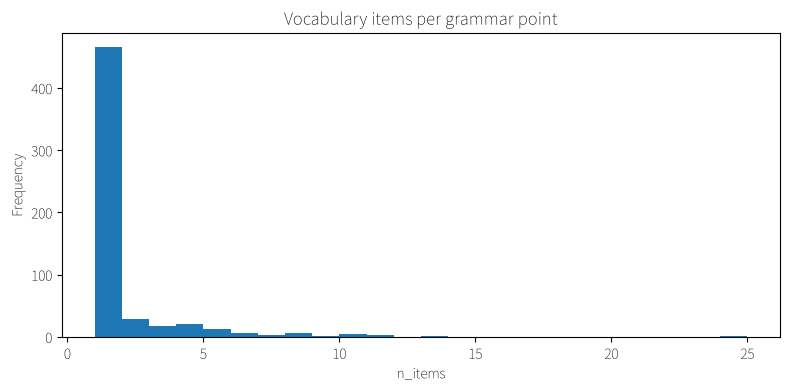

,line_no,prefix,number,n_items,label
0,17,一,1,24,方位名词：上、下、里、外、前、后、左、右、东、南、西、北；上边、下边、里边、外边、前边、后边...
6,131,一,7,13,一、二/两、三、四、五、六、七、八、九、零；十、百；半
147,2027,三,19,13,语气副词：白、并1、当然、到底、反正、根本、果然、简直、绝对、难道、其实、千万、确
133,1799,三,5,11,动宾式离合词：帮忙、点头、放假、干杯、见面、结婚、看病、睡觉、洗澡、理发、说话
137,1881,三,9,11,名量词：把、行、架、群、束、双、台、张、支、只、种
142,1959,三,14,11,时间副词：本来、才²、曾经、从来、赶紧、赶快、立刻、连忙、始终、已、早已
3,67,一,4,10,疑问代词：多、多少、几、哪、哪儿、哪里、哪些、什么、谁、怎么
5,109,一,6,10,指示代词：这、那、这儿、那儿、这里、那里、这些、那些、别的、有的
45,667,一,46,10,用“多、多少、几、哪、哪儿、哪里、哪些、什么、谁、怎么”提问
293,3647,五,8,10,语气副词：毕竞、不免、差（一）点儿、倒是、干脆、就4、居然、可”、明明、总算


In [18]:
df["n_items"].plot(kind="hist", bins=range(1, df["n_items"].max() + 2), figsize=(8, 4),
                     title="Vocabulary items per grammar point")
plt.xlabel("n_items")
plt.tight_layout()
plt.show()

df.nlargest(15, "n_items")[["line_no", "prefix", "number", "n_items", "label"]]

### 6.3 Total vocabulary items per grade level

Point count (section 3.1) and item count can diverge: a level with fewer
points but long enumerations still introduces a lot of vocabulary, so this
is a different view of curriculum size, not a duplicate of 3.1.

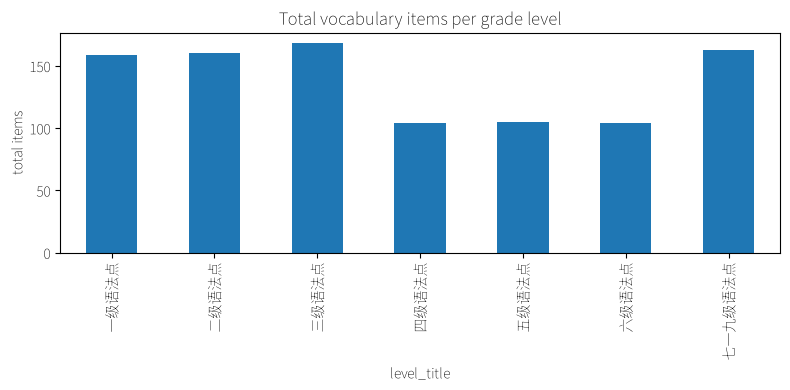

,total_items,mean_items_per_point,n_points
level_title,,,
一级语法点,159,3.312500,48
二级语法点,160,1.975309,81
三级语法点,168,2.074074,81
四级语法点,104,1.368421,76
五级语法点,105,1.478873,71
六级语法点,104,1.552239,67
七一九级语法点,163,1.101351,148


In [19]:
items_per_level = df.groupby("level_title")["n_items"].agg(["sum", "mean", "count"]).reindex(level_order)
items_per_level.columns = ["total_items", "mean_items_per_point", "n_points"]
items_per_level.plot(y="total_items", kind="bar", figsize=(8, 4), title="Total vocabulary items per grade level", legend=False)
plt.ylabel("total items")
plt.tight_layout()
plt.show()
items_per_level

### 6.4 Single-item vs multi-item points by category

Some categories (e.g. 固定短语, 四字格) are typically one fixed expression
per point; others (e.g. 名词/代词 word lists) bundle many synonyms/variants
under one point. This checks whether that pattern holds.

In [20]:
df["is_single_item"] = df["n_items"] == 1
single_vs_multi = df.groupby("category_top")["is_single_item"].agg(["mean", "count"]).rename(
    columns={"mean": "share_single_item", "count": "n_points"}
)
single_vs_multi.sort_values("n_points", ascending=False).head(20)

,share_single_item,n_points
category_top,,
词类,0.593137,204
句子的类型,0.972603,146
短语,1.000000,62
口语格式,1.000000,52
句子成分,0.722222,36
固定格式,1.000000,27
强调的方法,1.000000,13
提问的方法,0.700000,10
特殊表达法,0.857143,7
